In [ ]:
spike_sorted_sessions

In [ ]:
from behavior_utils import generate_behavior_summary_combined
from general_utils import find_ephys_sessions
from general_utils import smart_read_csv
import pandas as pd
from ephys_behavior import (
    get_the_mean_firing_rate_combined,   # ← updated name here
    correlate_firing_latent_multiple_variable
)
import os

# 1) find your sorted sessions
_, _, spike_sorted_sessions = find_ephys_sessions()
print("Sessions to process:", spike_sorted_sessions)


# 3) ensure results folder
results_folder = '/root/capsule/scratch/behavior_summary'
os.makedirs(results_folder, exist_ok=True)

# 4) iterate sessions
for sess in spike_sorted_sessions:
    try:
        print(f"\n=== Processing session {sess} ===")

        # a) behavior summary
        generate_behavior_summary_combined(
            session_names=[sess],
            save_result=True,
            save_folder=results_folder,
            save_name=f"behavior_summary-{sess}.csv"
        )

    except Exception as e:
        print(f"!! Error in session {sess}: {e}")
        continue


Found behavior NWB: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Successfully read behavior NWB from: /root/capsule/data/optogenetics_nwb/795396_2025-09-20_13-11-19.nwb
Plotting alias 'ForagingCompareThreshold' (latent: right_choice_probability)


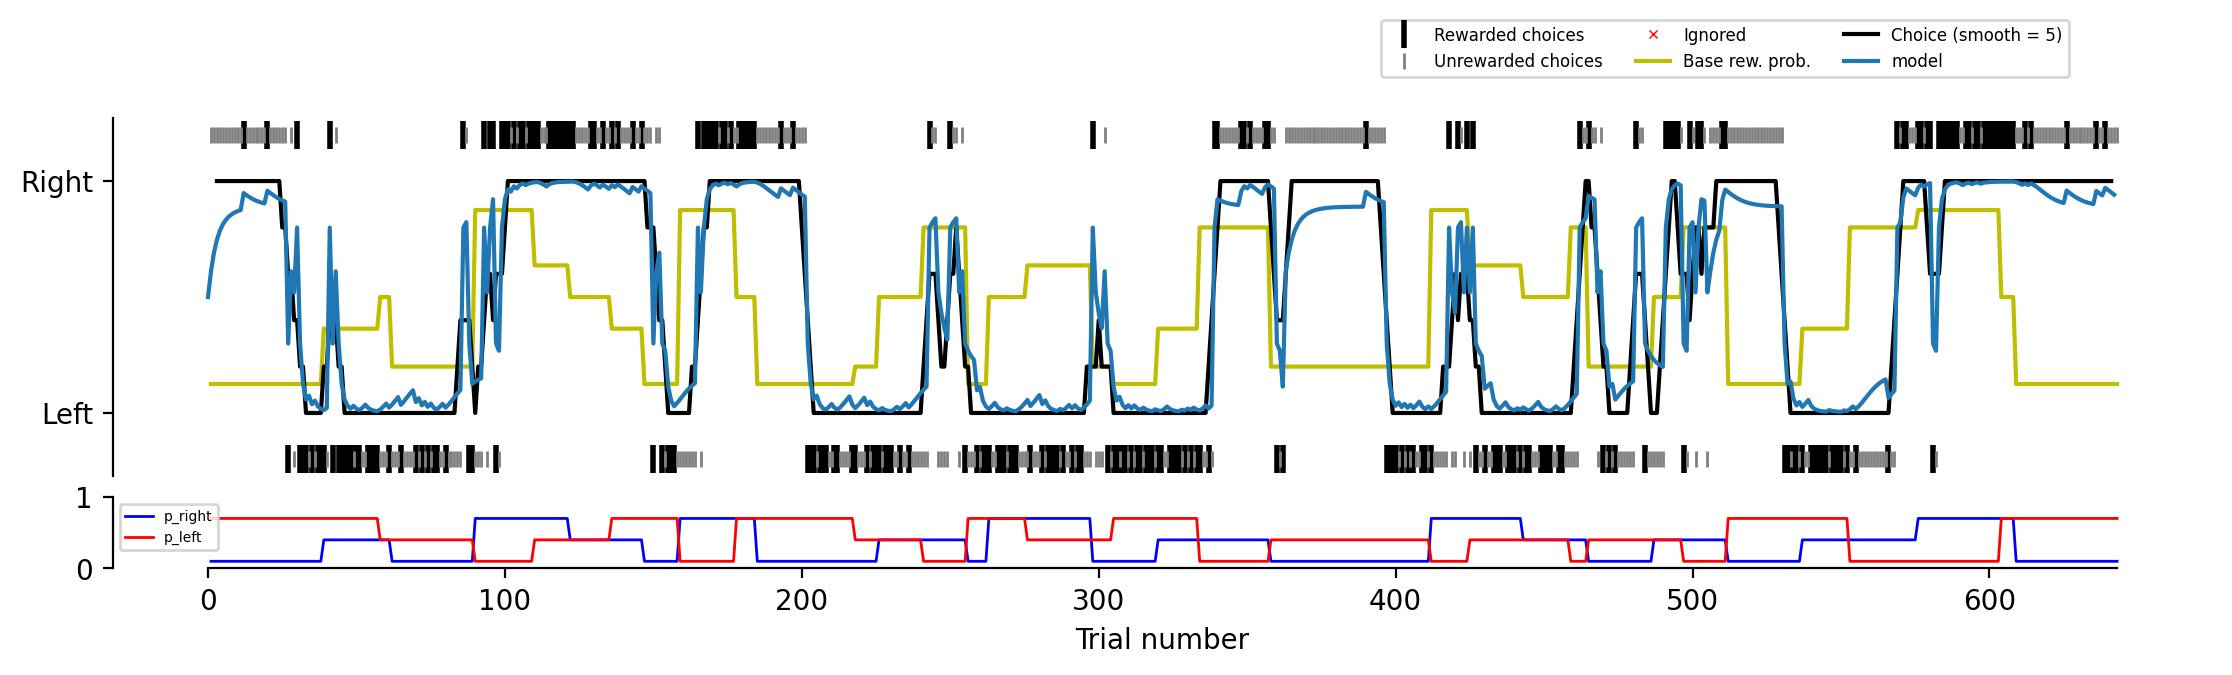

In [1]:
from general_visualization import plot_behavior_session
from nwb_utils import NWBUtils
from behavior_utils import get_fitted_model_names
from general_utils import find_behavior_sessions

import os

folder_path = '/root/capsule/data/behavior_nwb'  # Replace with your folder path

# List only files (exclude subdirectories)
behavior_sessions = [f for f in os.listdir(folder_path)
         if os.path.isfile(os.path.join(folder_path, f))]


behavior_sessions=['ecephys_795396_2025-09-20_13-11-19_sorted_2025-10-29_20-43-11']
for behavior_session in behavior_sessions:
        nwb_data=NWBUtils.read_behavior_nwb(session_name=behavior_session)
        plot_behavior_session(nwb_data=nwb_data,model_alias='ForagingCompareThreshold',latent_name='right_choice_probability')

In [ ]:
nwb_data=NWBUtils.read_behavior_nwb(session_name=behavior_session)